# Projet de Modélisation et Machine Learning - Diagramme HR

## 1) Détermination du type de problème

### 1.1 - Nature du problème

Nous avons un ensemble de données sans labels prédéfinis : nous ne savons pas à l’avance quelles étoiles appartiennent à quel groupe.

Type de problème : Clustering (apprentissage non supervisé)

Objectif : Identifier des regroupements d’étoiles dans le diagramme HR .

### 1.2 - Sélection des modèles 

- **K-Means** : \
Les clusters doivent avoir les mêmes formes et tailles (ce qui pourrait poser problème). \
Nécessite de choisir à l'avance le nombre de clusters.

- **DBSCAN** (Density-based Spatial Clustering of Applications with Noise) : \
Les clusters peuvent être de formes et tailles différentes 

- **Gaussian mixture models** (GMM) : \
Les clusters peuvent être de formes et tailles différentes


### 1.3 - Choix de la métrique pour évaluer les modèles

Comme il s'agit d'un apprentissage non supervisé il sera difficile d'évaluer le modèle. ????

## 2) Pré-traitement des données 

In [218]:
### Importation des modules 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn import decomposition
from sklearn.decomposition import PCA




### 2.1 - Chargement des données

In [219]:
data_true = pd.read_csv("data.csv")
print(data_true.columns)
print(data_true.head())
print(data_true.shape)

Index(['Catalog', 'HIP', 'Proxy', 'RAhms', 'DEdms', 'Vmag', 'VarFlag',
       'r_Vmag', 'RAdeg', 'DEdeg', 'AstroRef', 'Plx', 'pmRA', 'pmDE',
       'e_RAdeg', 'e_DEdeg', 'e_Plx', 'e_pmRA', 'e_pmDE', 'DE:RA', 'Plx:RA',
       'Plx:DE', 'pmRA:RA', 'pmRA:DE', 'pmRA:Plx', 'pmDE:RA', 'pmDE:DE',
       'pmDE:Plx', 'pmDE:pmRA', 'F1', 'F2', '---', 'BTmag', 'e_BTmag', 'VTmag',
       'e_VTmag', 'm_BTmag', 'B-V', 'e_B-V', 'r_B-V', 'V-I', 'e_V-I', 'r_V-I',
       'CombMag', 'Hpmag', 'e_Hpmag', 'Hpscat', 'o_Hpmag', 'm_Hpmag', 'Hpmax',
       'HPmin', 'Period', 'HvarType', 'moreVar', 'morePhoto', 'CCDM', 'n_CCDM',
       'Nsys', 'Ncomp', 'MultFlag', 'Source', 'Qual', 'm_HIP', 'theta', 'rho',
       'e_rho', 'dHp', 'e_dHp', 'Survey', 'Chart', 'Notes', 'HD', 'BD', 'CoD',
       'CPD', '(V-I)red', 'SpType', 'r_SpType'],
      dtype='object')
  Catalog  HIP Proxy        RAhms        DEdms  Vmag  VarFlag r_Vmag  \
0       H    1   NaN  00 00 00.22  +01 05 20.4  9.10      NaN      H   
1       H    2   N

Le dataset est constituées de données sur 118 218 étoiles et de 78 colonnes. Plusieurs de ces colonnes ne nous seront pas utiles.

### 2.2 - Visualisation des données

In [220]:
# Types de chaque colonne
print(data_true.dtypes)

Catalog      object
HIP           int64
Proxy        object
RAhms        object
DEdms        object
             ...   
CoD          object
CPD          object
(V-I)red    float64
SpType       object
r_SpType     object
Length: 78, dtype: object


                HIP      Vmag   VarFlag     RAdeg     DEdeg       Plx  \
HIP        1.000000  0.003751  0.022815  0.999513 -0.003517 -0.002868   
Vmag       0.003751  1.000000  0.441254  0.002829 -0.007384 -0.054949   
VarFlag    0.022815  0.441254  1.000000  0.022740  0.020087 -0.087664   
RAdeg      0.999513  0.002829  0.022740  1.000000 -0.003610 -0.003073   
DEdeg     -0.003517 -0.007384  0.020087 -0.003610  1.000000  0.001103   
Plx       -0.002868 -0.054949 -0.087664 -0.003073  0.001103  1.000000   
pmRA      -0.032329 -0.001165  0.008165 -0.032885  0.001581  0.008910   
pmDE      -0.012362 -0.051399  0.002665 -0.012239 -0.013896 -0.209806   
e_RAdeg    0.005589  0.186133  0.219122  0.004837 -0.006926  0.078872   
e_DEdeg    0.005067  0.187942  0.222543  0.004202 -0.010726  0.074768   
e_Plx      0.003545  0.324266  0.234460  0.002937 -0.009046  0.118504   
e_pmRA     0.007956  0.260811  0.212447  0.007012 -0.007746  0.114305   
e_pmDE    -0.000127  0.278234  0.236816 -0.001111 -

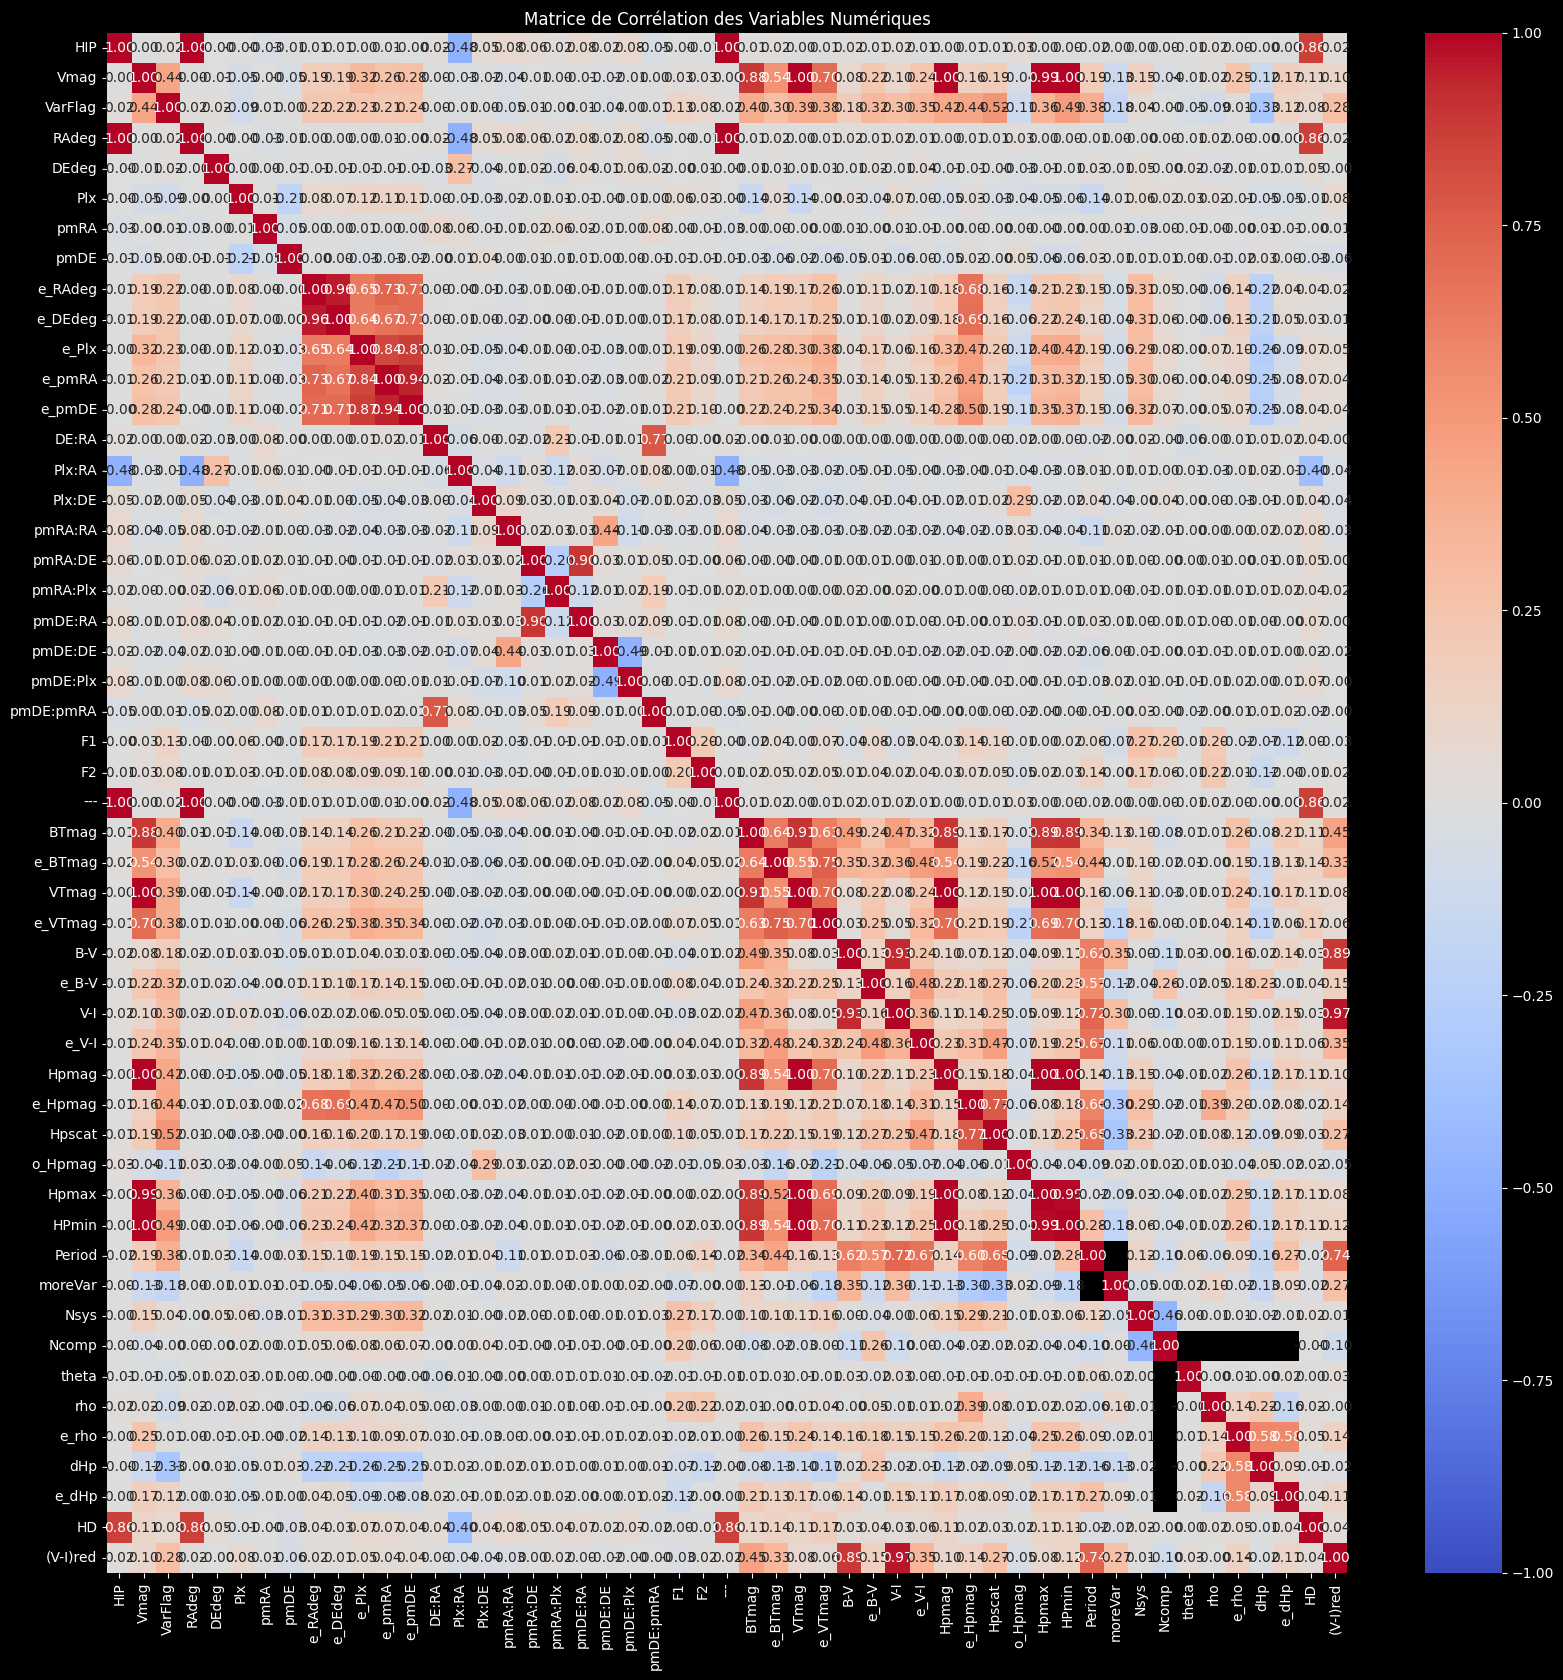

In [221]:
# Extraire seulement les données numériques
num_data = data_true.select_dtypes(include=['number'])

# Matrice de corrélation
corr_matrix = num_data.corr()
print(corr_matrix)

plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title(r"Matrice de Corrélation des Variables Numériques")
plt.show()

           HIP      Vmag       Plx       B-V
HIP   1.000000  0.003751 -0.002868  0.018040
Vmag  0.003751  1.000000 -0.054949  0.076026
Plx  -0.002868 -0.054949  1.000000  0.029421
B-V   0.018040  0.076026  0.029421  1.000000


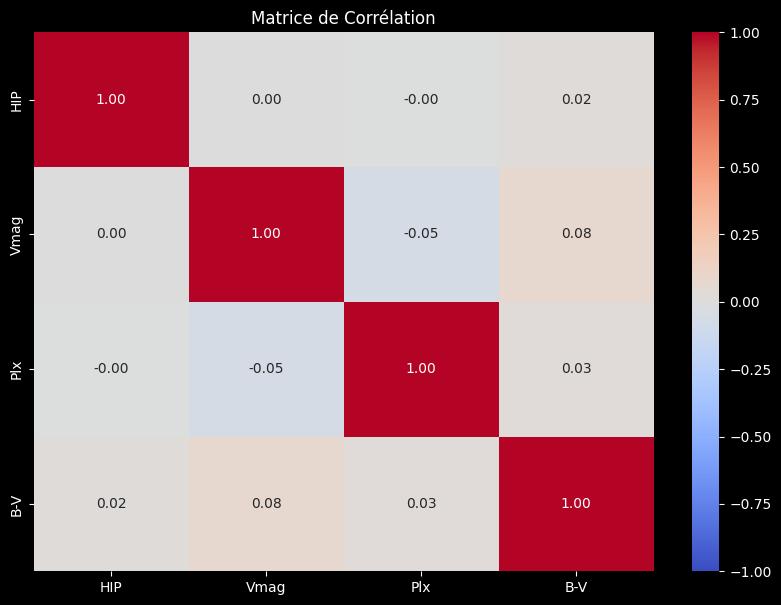

In [222]:
# Extraire quelques données qui semblent être pertinentes (pour une meilleure visualisation)

def matrice_corr(sub_data_name, data) :
    num_data = data.select_dtypes(include=['number'])
    sub_data = num_data[sub_data_name]
    corr_matrix_sub = sub_data.corr()
    print(corr_matrix_sub)

    plt.figure(figsize=(10, 7))
    sns.heatmap(corr_matrix_sub, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
    plt.title("Matrice de Corrélation")
    plt.show()

matrice_corr(['HIP', 'Vmag', 'Plx', 'B-V'], data_true)  



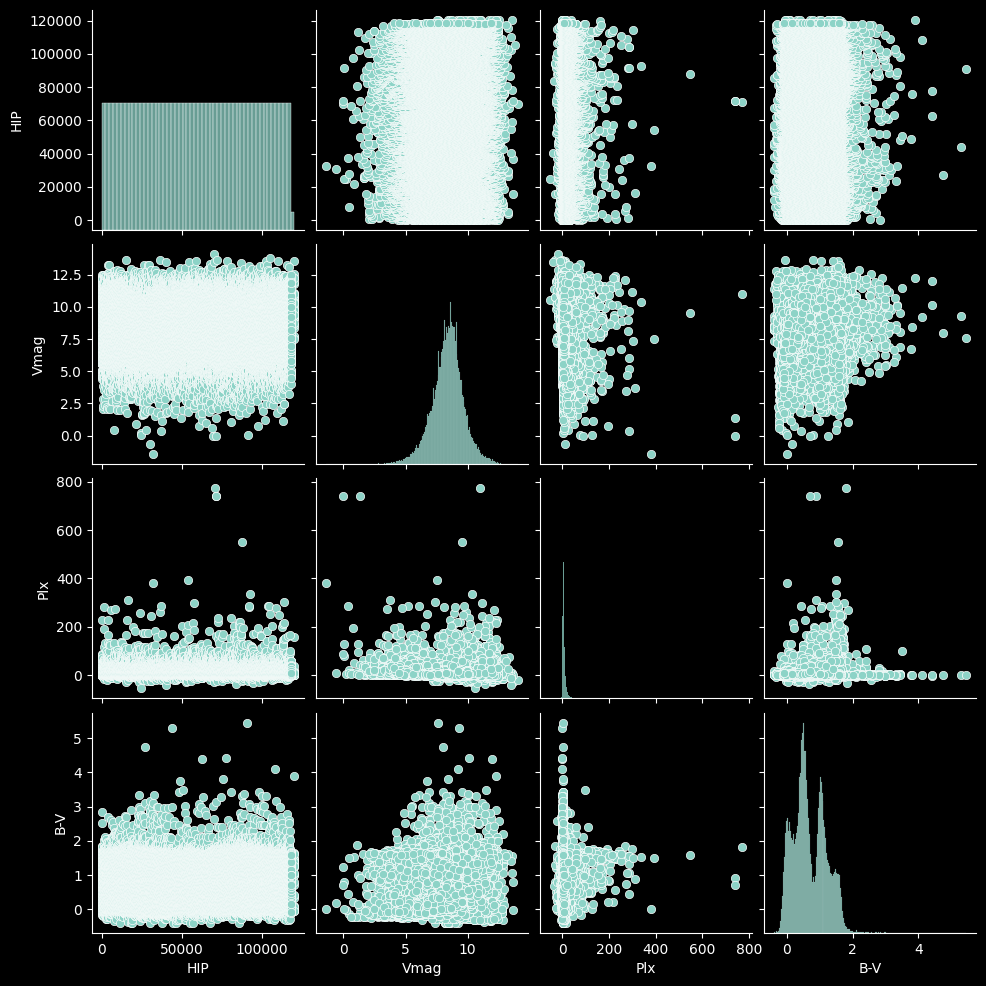

In [223]:
data_sub = data_true[['HIP', 'Vmag', 'Plx', 'B-V']]
sns.pairplot(data=data_sub)  # ?????

### 2.4 - Sélection et créations de variables d'entrainement pertinentes 


In [224]:
# Sélection des variables pertinentes 
data = data_true[['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']]

# Filtrer les étoiles avec une parallaxe positive et significative
data = data[data['Plx'] > 0]

# Calcul de la distance (en pc) 
data['Distance'] = 1/data['Plx'] * 1000  

# Calcul de la magnitude absolue 
data['AbsoluteMag'] = data['Vmag'] - 5 * np.log10(data['Distance'] / 10)   

# Fonction pour calculer la température effective des étoiles
def bv_to_temp(bv):
    return 4600 * ((1 / (0.92 * bv + 1.7)) + (1 / (0.92 * bv + 0.62)))

# Ajouter la température aux données
data['Temperature'] = bv_to_temp(data['B-V'])


Le type spectral est une variable catégorielle qui doit être convertie en une forme utilisable par un algorithme de clustering : 
(O, B, A, F, G, K, M) ---> (1, 2, 3, ...)

In [225]:
# Encodage du type spectral
encoder = LabelEncoder()
data['SpType_encoded'] = encoder.fit_transform(data['SpType'])

# Supression du type spectral 
data = data.drop(columns=['SpType'])

### 2.3 - Traitement des données manquantes

In [226]:
# Vérfifier les valeurs manquantes 
missing_data = data.isnull()
nb_missing_value = missing_data.sum()    # Nombre de valeurs manquantes par colonne
print(nb_missing_value)


HIP                 0
Vmag                0
Plx                 0
B-V               887
Distance            0
AbsoluteMag         0
Temperature       887
SpType_encoded      0
dtype: int64


In [227]:
# Afficher le pourcentage de valeurs manquantes
missing_percent = missing_data.mean() * 100
print(missing_percent)

HIP               0.000000
Vmag              0.000000
Plx               0.000000
B-V               0.780055
Distance          0.000000
AbsoluteMag       0.000000
Temperature       0.780055
SpType_encoded    0.000000
dtype: float64


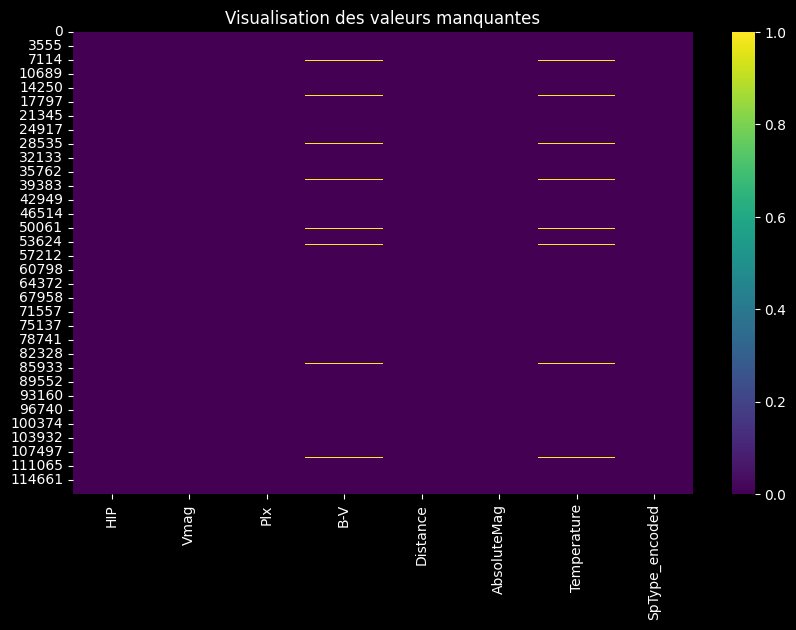

In [228]:
# Heatmap des valeurs manquantes
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cmap="viridis")
plt.title("Visualisation des valeurs manquantes")
plt.show()

In [229]:
# Traiter les valeurs manquantes : comme on a énormément de données, on peut supprimer les lignes avec les valeurs manquantes dans les colonnes pertinentes 
data_clean = data.dropna(subset=['HIP', 'Vmag', 'Plx', 'B-V', 'Distance', 'AbsoluteMag', 'Temperature', 'SpType_encoded'])
print(data_clean.shape)

## Est-ce la meilleure façon ???


(112823, 8)


In [230]:
X = data_clean
X

,HIP,Vmag,Plx,B-V,Distance,AbsoluteMag,Temperature,SpType_encoded
0,1,9.10,3.54,0.482,282.485876,1.845016,6471.667826,1809
1,2,9.27,21.90,0.999,45.662100,5.972221,4745.140425,3178
2,3,6.61,2.81,-0.019,355.871886,-1.146468,10368.595588,1353
3,4,8.06,7.75,0.370,129.032258,2.506509,7044.130880,1604
4,5,8.55,2.87,0.902,348.432056,0.839409,4991.060700,2649
...,...,...,...,...,...,...,...,...
118213,118318,6.99,1.92,1.595,520.833333,-1.593494,3655.993639,3015
118214,118319,8.23,10.63,0.639,94.073377,3.362666,5818.920292,2296
118215,118320,7.59,5.00,0.999,200.000000,1.084850,4745.140425,2768
118216,118321,9.20,19.22,0.698,52.029136,5.618767,5608.544902,2470


### 2.5 - Vérification de nouvelles variables 


                Distance  AbsoluteMag  Temperature  SpType_encoded       B-V
Distance        1.000000     -0.33716    -0.003166        0.015183  0.034706
AbsoluteMag    -0.337160      1.00000    -0.112810        0.120800 -0.054170
Temperature    -0.003166     -0.11281     1.000000       -0.806002 -0.930123
SpType_encoded  0.015183      0.12080    -0.806002        1.000000  0.826801
B-V             0.034706     -0.05417    -0.930123        0.826801  1.000000


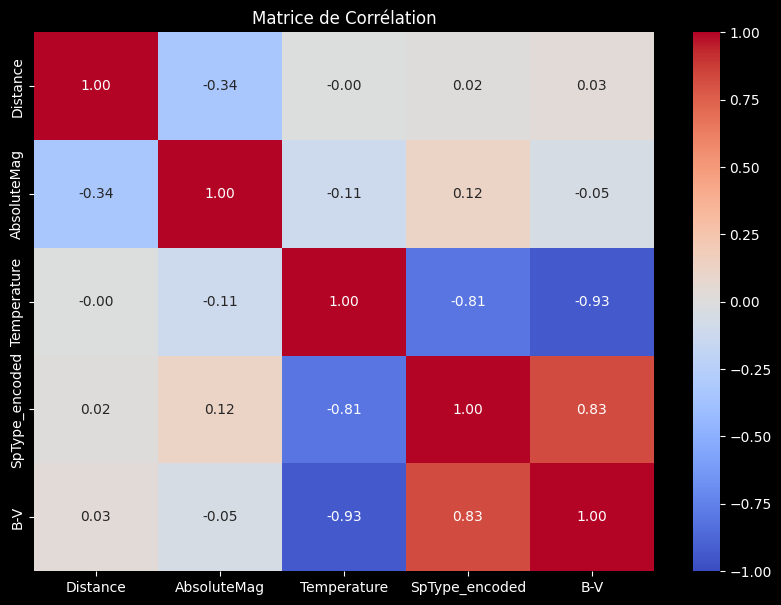

In [231]:
matrice_corr(['Distance', 'AbsoluteMag', 'Temperature', 'SpType_encoded', 'B-V'], data)

### 2.6 - Normalisation des variables d'entrainement 

In [232]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
X_scaled_df

,HIP,Vmag,Plx,B-V,Distance,AbsoluteMag,Temperature,SpType_encoded
0,-1.727453,0.618564,-0.352599,-0.454175,-0.073805,0.074351,0.130850,-0.227177
1,-1.727424,0.751857,1.280499,0.615606,-0.176107,1.801635,-0.713214,1.115105
2,-1.727394,-1.333777,-0.417532,-1.490848,-0.042104,-1.177621,2.035976,-0.674277
3,-1.727365,-0.196871,0.021875,-0.685926,-0.140093,0.351193,0.410715,-0.428176
4,-1.727336,0.187324,-0.412195,0.414893,-0.045318,-0.346508,-0.592988,0.596429
...,...,...,...,...,...,...,...,...
112818,1.731239,-1.035829,-0.496696,1.848854,0.029155,-1.364707,-1.245675,0.955286
112819,1.731268,-0.063579,0.278047,-0.129309,-0.155194,0.709505,-0.188265,0.250319
112820,1.731297,-0.565385,-0.222734,0.615606,-0.109437,-0.243788,-0.713214,0.713107
112821,1.731326,0.696971,1.042117,-0.007226,-0.173356,1.653710,-0.291113,0.420923


In [233]:
## Scaler MinMax
#scaler = MinMaxScaler()
#X_scaled = scaler.fit_transform(X)
#X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
#X_scaled_df
#Does not reduce the effect of outliers

In [234]:
## Robust scaler 
#scaler = RobustScaler()
#X_scaled = scaler.fit_transform(X)
#X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
#X_scaled_df

#scaler = PowerTransformer()
#X_scaled = scaler.fit_transform(X)
#X_scaled_df = pd.DataFrame(X_scaled, columns = X.columns)
#X_scaled_df

#StandardScaler, 
# MinMaxScaler, mélange des points 
# RobustScaler, score approx 0.9 mais  
# QuantileTransformer, Uniform- no, Normal- forme de cluster se rapproche mais bas score
# Normalizer, mélange des groupes
# MaxAbsScaler, similaire à MinMax
# PowerTransformer, similaire à quantile normal

### 2.7 - Séparation du dataset (train/validation/test)

Taille du train : (78976, 8)
Taille du validation : (16923, 8)
Taille du test : (16924, 8)


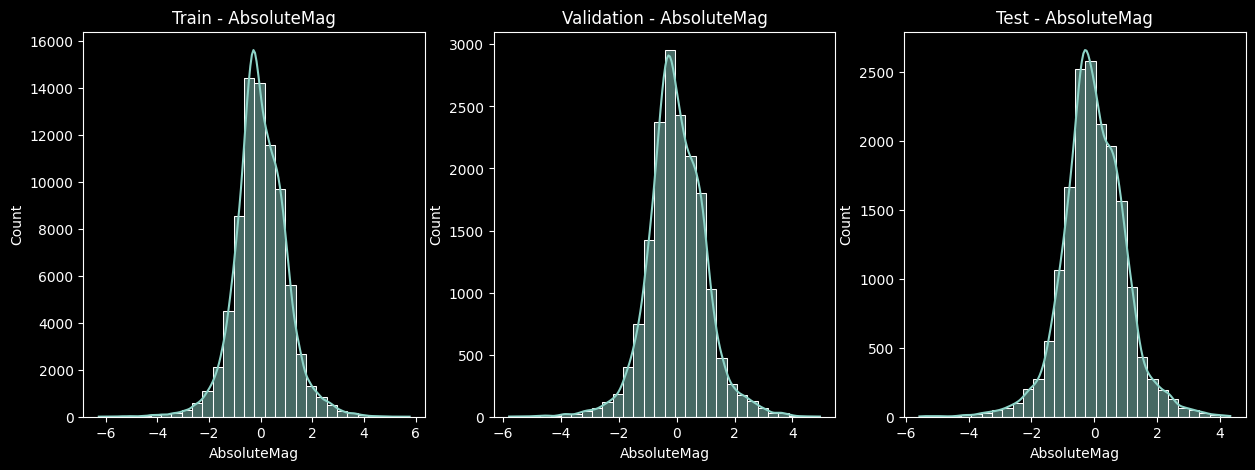

In [235]:
# Séparation en train/validation/test
X_train, X_temp = train_test_split(X_scaled_df, test_size=0.3, random_state=0)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=0)

print(f"Taille du train : {X_train.shape}")
print(f"Taille du validation : {X_val.shape}")
print(f"Taille du test : {X_test.shape}")
#print(X_train)

# Visualiser les données de chaque ensemble (par exemple avec AbsoluteMag)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(X_train['AbsoluteMag'], bins=30, kde=True, ax=axes[0]).set_title("Train - AbsoluteMag")
sns.histplot(X_val['AbsoluteMag'], bins=30, kde=True, ax=axes[1]).set_title("Validation - AbsoluteMag")
sns.histplot(X_test['AbsoluteMag'], bins=30, kde=True, ax=axes[2]).set_title("Test - AbsoluteMag")
plt.show()

## 3) K_Means (sans PCA)

### 3.1 - Entrainement 

In [236]:
# On vérifie qu'il n'y pas de valeurs manquantes dans les données
print(X_train.isnull().sum()) 

HIP               0
Vmag              0
Plx               0
B-V               0
Distance          0
AbsoluteMag       0
Temperature       0
SpType_encoded    0
dtype: int64


In [237]:
# Entraînement du modèle k=4
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(X_train)

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



KMeans(n_clusters=4, random_state=0)

In [238]:
print("Centres des clusters :")
print(kmeans.cluster_centers_) 

Centres des clusters :
[[ 5.03833007e-03 -3.77930781e-01 -2.38101803e-01 -1.16069812e+00
   2.29777759e-02 -4.66867226e-01  1.33216842e+00 -1.33864755e+00]
 [-1.18660616e-02  5.11262725e-01  4.75820434e-01 -1.49885798e-01
  -1.34692551e-01  9.01250115e-01 -1.05336462e-01  1.79081448e-01]
 [ 9.56295308e-03 -2.80600625e-01 -3.43667632e-01  1.05782597e+00
   6.87410473e-02 -6.31922325e-01 -9.07371729e-01  8.28790748e-01]
 [ 1.31101326e-01  4.38529090e-01 -6.66109356e-01  3.28980659e-01
   3.13714876e+01 -5.01649714e+00 -1.00256477e-01  3.48102979e-01]]


In [239]:
# Prédire les clusters pour l'ensemble d'entraînement
train_clusters = kmeans.predict(X_train)

# Ajouter les clusters comme une nouvelle colonne dans X_train
X_train['Cluster'] = train_clusters

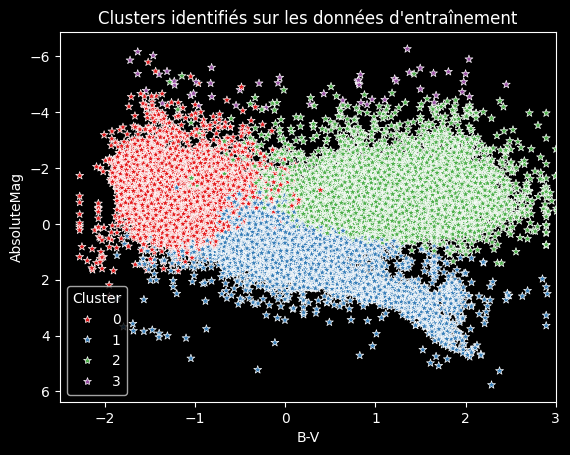

In [240]:
sns.scatterplot(x=X_train['B-V'], y=X_train['AbsoluteMag'], hue=X_train['Cluster'], palette="Set1", marker="*")   
plt.title("Clusters identifiés sur les données d'entraînement")
plt.xlim(-2.5, 3)
plt.gca().invert_yaxis()  # il faut inverser l'axe de AbsoluteMag par convention du diagramme HR
plt.show()

# bon graphe mais pas bons clusters 
# pb on ne voit pas distinctement les clusters : faire pca avec 2 ou 3 comp

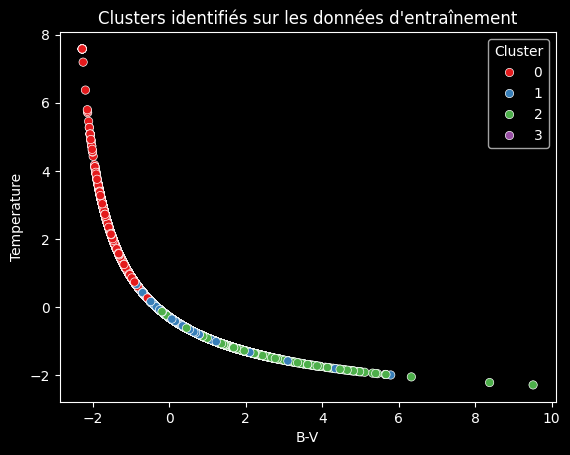

In [241]:
sns.scatterplot(x=X_train['B-V'], y=X_train['Temperature'], hue=X_train['Cluster'], palette="Set1")
plt.title("Clusters identifiés sur les données d'entraînement")
plt.show()

### 3.2 - Évaluation du modèle

### 

In [242]:
# Evaluer la qualité des clusters : Le silhouette score mesure à quel point chaque point est bien classé dans son cluster comparé aux autres clusters.
score = silhouette_score(X_train, kmeans.labels_) 
print("Silhouette Score :", score)

# Si la valeur est proche de 1 alors on a un meilleur clustering


Silhouette Score : 0.3271303353732868


In [243]:
#samples = silhouette_samples(X_train, kmeans.labels_)
#plt.bar(range(len(samples)), samples)
#plt.title("Silhouette Coefficient for each point")
#plt.xlabel("Point index")
#plt.ylabel("Silhouette score")
#plt.show()

## 4) K_Means (avec PCA)

In [244]:
# On affiche le dataset de base (sans aucune modification)
data_true

,Catalog,HIP,Proxy,RAhms,DEdms,Vmag,VarFlag,r_Vmag,RAdeg,DEdeg,...,Survey,Chart,Notes,HD,BD,CoD,CPD,(V-I)red,SpType,r_SpType
0,H,1,NaN,00 00 00.22,+01 05 20.4,9.10,NaN,H,0.000912,1.089013,...,S,NaN,NaN,224700.0,B+00 5077,NaN,NaN,0.66,F5,S
1,H,2,NaN,00 00 00.91,-19 29 55.8,9.27,NaN,G,0.003797,-19.498837,...,NaN,NaN,NaN,224690.0,B-20 6688,NaN,NaN,1.04,K3V,4
2,H,3,NaN,00 00 01.20,+38 51 33.4,6.61,NaN,G,0.005008,38.859286,...,S,NaN,NaN,224699.0,B+38 5108,NaN,NaN,0.00,B9,S
3,H,4,NaN,00 00 02.01,-51 53 36.8,8.06,NaN,H,0.008382,-51.893546,...,S,NaN,NaN,224707.0,NaN,NaN,P-52 12237,0.43,F0V,2
4,H,5,NaN,00 00 02.39,-40 35 28.4,8.55,NaN,H,0.009965,-40.591224,...,NaN,NaN,NaN,224705.0,NaN,C-41 15372,P-41 9991,0.95,G8III,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118213,H,118318,NaN,23 59 51.30,+11 40 25.4,6.99,1.0,H,359.963744,11.673709,...,S,NaN,NaN,224673.0,B+10 5018,NaN,NaN,1.56,K2,S
118214,H,118319,NaN,23 59 53.74,-22 25 41.4,8.23,NaN,G,359.973913,-22.428180,...,S,NaN,NaN,224693.0,NaN,C-23 18108,P-23 8366,0.70,G2V,4
118215,H,118320,NaN,23 59 54.25,+05 57 23.9,7.59,NaN,H,359.976057,5.956638,...,S,NaN,NaN,224689.0,B+05 5245,NaN,NaN,0.98,K0,S
118216,H,118321,NaN,23 59 54.78,-64 22 21.3,9.20,NaN,G,359.978239,-64.372572,...,NaN,NaN,NaN,224685.0,NaN,C-65 2958,P-65 4188,0.75,G5V,1


In [245]:
## On calcule les 3 grandeurs dans data_pca_calcul afin de les utiliser pour la pca

# Copie pour éviter de modifier directement le dataset de base
data_pca_calcul = data_true.copy()

# Filtrer les étoiles avec une parallaxe positive et significative
data_pca_calcul = data_pca_calcul[data_pca_calcul['Plx'] > 0]

# Calcul de la distance (en pc) 
data_pca_calcul['Distance'] = 1/data_pca_calcul['Plx'] * 1000  

# Calcul de la magnitude absolue 
data_pca_calcul['AbsoluteMag'] = data_pca_calcul['Vmag'] - 5 * np.log10(data_pca_calcul['Distance'] / 10)   

# Fonction pour calculer la température effective des étoiles
def bv_to_temp(bv):
    return 4600 * ((1 / (0.92 * bv + 1.7)) + (1 / (0.92 * bv + 0.62)))

# Ajouter la température aux données
data_pca_calcul['Temperature'] = bv_to_temp(data_pca_calcul['B-V'])

# Vérifier que les colonnes calculées sont bien dans data_pca_calcul
print("Distance est une colonne dans data_pca_calcul:", "Distance" in data_pca_calcul)
print("AbsoluteMag est une colonne dans data_pca_calcul:", "AbsoluteMag" in data_pca_calcul)
print("Temperature est une colonne dans data_pca_calcul:", "Temperature" in data_pca_calcul)

data_pca_calcul

Distance est une colonne dans data_pca_calcul: True
AbsoluteMag est une colonne dans data_pca_calcul: True
Temperature est une colonne dans data_pca_calcul: True


,Catalog,HIP,Proxy,RAhms,DEdms,Vmag,VarFlag,r_Vmag,RAdeg,DEdeg,...,HD,BD,CoD,CPD,(V-I)red,SpType,r_SpType,Distance,AbsoluteMag,Temperature
0,H,1,NaN,00 00 00.22,+01 05 20.4,9.10,NaN,H,0.000912,1.089013,...,224700.0,B+00 5077,NaN,NaN,0.66,F5,S,282.485876,1.845016,6471.667826
1,H,2,NaN,00 00 00.91,-19 29 55.8,9.27,NaN,G,0.003797,-19.498837,...,224690.0,B-20 6688,NaN,NaN,1.04,K3V,4,45.662100,5.972221,4745.140425
2,H,3,NaN,00 00 01.20,+38 51 33.4,6.61,NaN,G,0.005008,38.859286,...,224699.0,B+38 5108,NaN,NaN,0.00,B9,S,355.871886,-1.146468,10368.595588
3,H,4,NaN,00 00 02.01,-51 53 36.8,8.06,NaN,H,0.008382,-51.893546,...,224707.0,NaN,NaN,P-52 12237,0.43,F0V,2,129.032258,2.506509,7044.130880
4,H,5,NaN,00 00 02.39,-40 35 28.4,8.55,NaN,H,0.009965,-40.591224,...,224705.0,NaN,C-41 15372,P-41 9991,0.95,G8III,2,348.432056,0.839409,4991.060700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118213,H,118318,NaN,23 59 51.30,+11 40 25.4,6.99,1.0,H,359.963744,11.673709,...,224673.0,B+10 5018,NaN,NaN,1.56,K2,S,520.833333,-1.593494,3655.993639
118214,H,118319,NaN,23 59 53.74,-22 25 41.4,8.23,NaN,G,359.973913,-22.428180,...,224693.0,NaN,C-23 18108,P-23 8366,0.70,G2V,4,94.073377,3.362666,5818.920292
118215,H,118320,NaN,23 59 54.25,+05 57 23.9,7.59,NaN,H,359.976057,5.956638,...,224689.0,B+05 5245,NaN,NaN,0.98,K0,S,200.000000,1.084850,4745.140425
118216,H,118321,NaN,23 59 54.78,-64 22 21.3,9.20,NaN,G,359.978239,-64.372572,...,224685.0,NaN,C-65 2958,P-65 4188,0.75,G5V,1,52.029136,5.618767,5608.544902


In [246]:
# Afficher les valeurs manquantes 
missing_data = data_pca_calcul.isnull()
nb_missing_value = missing_data.sum()

total_rows = len(data_true)
for col, val in nb_missing_value.items():
    if val > 0:
        percent = (val / total_rows) * 100
        print(f"{col} : {val} NaNs ({percent:.2f}%)")


Proxy : 103157 NaNs (87.26%)
VarFlag : 103202 NaNs (87.30%)
AstroRef : 100675 NaNs (85.16%)
F2 : 1393 NaNs (1.18%)
BTmag : 2696 NaNs (2.28%)
e_BTmag : 2696 NaNs (2.28%)
VTmag : 2640 NaNs (2.23%)
e_VTmag : 2640 NaNs (2.23%)
m_BTmag : 101507 NaNs (85.86%)
B-V : 887 NaNs (0.75%)
e_B-V : 887 NaNs (0.75%)
r_B-V : 887 NaNs (0.75%)
V-I : 887 NaNs (0.75%)
e_V-I : 887 NaNs (0.75%)
CombMag : 103281 NaNs (87.36%)
Hpscat : 786 NaNs (0.66%)
o_Hpmag : 786 NaNs (0.66%)
m_Hpmag : 101141 NaNs (85.55%)
Hpmax : 786 NaNs (0.66%)
HPmin : 786 NaNs (0.66%)
Period : 111507 NaNs (94.32%)
HvarType : 45077 NaNs (38.13%)
moreVar : 106287 NaNs (89.91%)
morePhoto : 110567 NaNs (93.53%)
CCDM : 95330 NaNs (80.64%)
n_CCDM : 95330 NaNs (80.64%)
Nsys : 95330 NaNs (80.64%)
MultFlag : 96731 NaNs (81.82%)
Source : 110786 NaNs (93.71%)
Qual : 94419 NaNs (79.87%)
m_HIP : 102984 NaNs (87.11%)
theta : 102984 NaNs (87.11%)
rho : 102984 NaNs (87.11%)
e_rho : 102984 NaNs (87.11%)
dHp : 102984 NaNs (87.11%)
e_dHp : 102984 NaNs (87

À partir de l'affichage précédent, on selectionne les colonnes inutiles :
- Catalog
- HIP
- Proxy
- VarFlag
- AstroRef
- m_BTmag
- CombMag
- m_Hpmag
- Period
- HvarType
- moreVar
- morePhoto
- CCDM
- n_CCDM
- Nsys
- MultFlag
- Source
- Qual
- m_HIP
- theta
- rho
- e_rho
- dHp
- e_dHp
- Survey
- Chart
- Notes
- HD
- BD
- CoD
- CPD



In [247]:
# On supprime ces colonnes dans data_pca_calcul
colonnes_inutiles = [
    "Catalog", "Proxy", "VarFlag", "AstroRef", "m_BTmag", "CombMag",
    "m_Hpmag", "Period", "HvarType", "moreVar", "morePhoto", "CCDM", "n_CCDM",
    "Nsys", "MultFlag", "Source", "Qual", "m_HIP", "theta", "rho", "e_rho",
    "dHp", "e_dHp", "Survey", "Chart", "Notes", "HD", "BD", "CoD", "CPD"
]
data_pca_modified = data_pca_calcul.drop(columns=colonnes_inutiles)
data_pca_modified

,HIP,RAhms,DEdms,Vmag,r_Vmag,RAdeg,DEdeg,Plx,pmRA,pmDE,...,o_Hpmag,Hpmax,HPmin,Ncomp,(V-I)red,SpType,r_SpType,Distance,AbsoluteMag,Temperature
0,1,00 00 00.22,+01 05 20.4,9.10,H,0.000912,1.089013,3.54,-5.20,-1.88,...,87.0,9.17,9.24,1.0,0.66,F5,S,282.485876,1.845016,6471.667826
1,2,00 00 00.91,-19 29 55.8,9.27,G,0.003797,-19.498837,21.90,181.21,-0.93,...,120.0,9.37,9.44,1.0,1.04,K3V,4,45.662100,5.972221,4745.140425
2,3,00 00 01.20,+38 51 33.4,6.61,G,0.005008,38.859286,2.81,5.24,-2.91,...,127.0,6.60,6.62,1.0,0.00,B9,S,355.871886,-1.146468,10368.595588
3,4,00 00 02.01,-51 53 36.8,8.06,H,0.008382,-51.893546,7.75,62.85,0.16,...,201.0,8.12,8.18,1.0,0.43,F0V,2,129.032258,2.506509,7044.130880
4,5,00 00 02.39,-40 35 28.4,8.55,H,0.009965,-40.591224,2.87,2.53,9.07,...,161.0,8.68,8.74,1.0,0.95,G8III,2,348.432056,0.839409,4991.060700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118213,118318,23 59 51.30,+11 40 25.4,6.99,H,359.963744,11.673709,1.92,-2.16,2.09,...,92.0,7.08,7.12,1.0,1.56,K2,S,520.833333,-1.593494,3655.993639
118214,118319,23 59 53.74,-22 25 41.4,8.23,G,359.973913,-22.428180,10.63,148.74,27.53,...,118.0,8.34,8.39,1.0,0.70,G2V,4,94.073377,3.362666,5818.920292
118215,118320,23 59 54.25,+05 57 23.9,7.59,H,359.976057,5.956638,5.00,20.92,-35.26,...,86.0,7.74,7.77,1.0,0.98,K0,S,200.000000,1.084850,4745.140425
118216,118321,23 59 54.78,-64 22 21.3,9.20,G,359.978239,-64.372572,19.22,216.99,106.46,...,145.0,9.28,9.36,1.0,0.75,G5V,1,52.029136,5.618767,5608.544902


In [248]:
# On affiche les noms des colonnes de data_pca_modified 
data_pca_modified.columns

# Une colonne inconnue "---" est présente dans data_true et donc aussi dans data_pca_modified, il faut l'enlever 
data_pca_modified_2 = data_pca_modified.drop(columns='---')
data_pca_modified_2

,HIP,RAhms,DEdms,Vmag,r_Vmag,RAdeg,DEdeg,Plx,pmRA,pmDE,...,o_Hpmag,Hpmax,HPmin,Ncomp,(V-I)red,SpType,r_SpType,Distance,AbsoluteMag,Temperature
0,1,00 00 00.22,+01 05 20.4,9.10,H,0.000912,1.089013,3.54,-5.20,-1.88,...,87.0,9.17,9.24,1.0,0.66,F5,S,282.485876,1.845016,6471.667826
1,2,00 00 00.91,-19 29 55.8,9.27,G,0.003797,-19.498837,21.90,181.21,-0.93,...,120.0,9.37,9.44,1.0,1.04,K3V,4,45.662100,5.972221,4745.140425
2,3,00 00 01.20,+38 51 33.4,6.61,G,0.005008,38.859286,2.81,5.24,-2.91,...,127.0,6.60,6.62,1.0,0.00,B9,S,355.871886,-1.146468,10368.595588
3,4,00 00 02.01,-51 53 36.8,8.06,H,0.008382,-51.893546,7.75,62.85,0.16,...,201.0,8.12,8.18,1.0,0.43,F0V,2,129.032258,2.506509,7044.130880
4,5,00 00 02.39,-40 35 28.4,8.55,H,0.009965,-40.591224,2.87,2.53,9.07,...,161.0,8.68,8.74,1.0,0.95,G8III,2,348.432056,0.839409,4991.060700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118213,118318,23 59 51.30,+11 40 25.4,6.99,H,359.963744,11.673709,1.92,-2.16,2.09,...,92.0,7.08,7.12,1.0,1.56,K2,S,520.833333,-1.593494,3655.993639
118214,118319,23 59 53.74,-22 25 41.4,8.23,G,359.973913,-22.428180,10.63,148.74,27.53,...,118.0,8.34,8.39,1.0,0.70,G2V,4,94.073377,3.362666,5818.920292
118215,118320,23 59 54.25,+05 57 23.9,7.59,H,359.976057,5.956638,5.00,20.92,-35.26,...,86.0,7.74,7.77,1.0,0.98,K0,S,200.000000,1.084850,4745.140425
118216,118321,23 59 54.78,-64 22 21.3,9.20,G,359.978239,-64.372572,19.22,216.99,106.46,...,145.0,9.28,9.36,1.0,0.75,G5V,1,52.029136,5.618767,5608.544902


In [249]:
# Enlever les NaN restants 
data_pca_modified_3 = data_pca_modified_2.dropna(axis=0)

In [250]:
## Il faut maintenant encoder les colonnes qui ne sont pas des int ou des float 

# Pour cela, on commence par afficher le type de chaque colonne 
print(data_pca_modified_3.dtypes)

HIP              int64
RAhms           object
DEdms           object
Vmag           float64
r_Vmag          object
RAdeg          float64
DEdeg          float64
Plx            float64
pmRA           float64
pmDE           float64
e_RAdeg        float64
e_DEdeg        float64
e_Plx          float64
e_pmRA         float64
e_pmDE         float64
DE:RA          float64
Plx:RA         float64
Plx:DE         float64
pmRA:RA        float64
pmRA:DE        float64
pmRA:Plx       float64
pmDE:RA        float64
pmDE:DE        float64
pmDE:Plx       float64
pmDE:pmRA      float64
F1             float64
F2             float64
BTmag          float64
e_BTmag        float64
VTmag          float64
e_VTmag        float64
B-V            float64
e_B-V          float64
r_B-V           object
V-I            float64
e_V-I          float64
r_V-I           object
Hpmag          float64
e_Hpmag        float64
Hpscat         float64
o_Hpmag        float64
Hpmax          float64
HPmin          float64
Ncomp      

In [251]:
# Pour encoder ces colonnes, il faut ajouter leur nom dans une liste 
cols_encoder = []
for col, dtype in data_pca_modified_3.dtypes.items():
    if dtype not in ["float64", "int64"]:
        cols_encoder.append(col)

print("Colonnes à encoder :", cols_encoder)


Colonnes à encoder : ['RAhms', 'DEdms', 'r_Vmag', 'r_B-V', 'r_V-I', 'SpType', 'r_SpType']


In [252]:
# Encodage 
label_encoders = {}
for col in cols_encoder:
    if col in data_pca_modified_3.columns:
        le = LabelEncoder()
        data_pca_modified_3.loc[:, col] = le.fit_transform(data_pca_modified_3[col].astype(str))
        label_encoders[col] = le
    else:
        print(f"Colonne '{col}' non trouvée dans le DataFrame")

# On vérifie qu'on a bien des int64 ou float64 après encodage
data_pca_modified_3
print(data_pca_modified_3.dtypes)

HIP              int64
RAhms           object
DEdms           object
Vmag           float64
r_Vmag          object
RAdeg          float64
DEdeg          float64
Plx            float64
pmRA           float64
pmDE           float64
e_RAdeg        float64
e_DEdeg        float64
e_Plx          float64
e_pmRA         float64
e_pmDE         float64
DE:RA          float64
Plx:RA         float64
Plx:DE         float64
pmRA:RA        float64
pmRA:DE        float64
pmRA:Plx       float64
pmDE:RA        float64
pmDE:DE        float64
pmDE:Plx       float64
pmDE:pmRA      float64
F1             float64
F2             float64
BTmag          float64
e_BTmag        float64
VTmag          float64
e_VTmag        float64
B-V            float64
e_B-V          float64
r_B-V           object
V-I            float64
e_V-I          float64
r_V-I           object
Hpmag          float64
e_Hpmag        float64
Hpscat         float64
o_Hpmag        float64
Hpmax          float64
HPmin          float64
Ncomp      

In [253]:
# Normaliser les donnnées (à modifier)
scaler = StandardScaler()
data_scaled_pca = scaler.fit_transform(data_pca_modified_3)
data_scaled_df_pca = pd.DataFrame(data_scaled_pca, columns = data_pca_modified_3.columns)
data_scaled_df_pca


,HIP,RAhms,DEdms,Vmag,r_Vmag,RAdeg,DEdeg,Plx,pmRA,pmDE,...,o_Hpmag,Hpmax,HPmin,Ncomp,(V-I)red,SpType,r_SpType,Distance,AbsoluteMag,Temperature
0,-1.732208,-1.731760,-1.703698,0.733371,0.458484,-1.757984,0.079773,-0.400220,-0.048319,0.183085,...,-0.578672,0.731156,0.718645,-0.324089,-0.137231,-0.183012,0.680569,-0.075417,0.151913,0.111620
1,-1.732179,-1.731728,0.418300,0.875879,-2.089157,-1.757956,-0.420904,1.751265,2.403981,0.196846,...,0.229385,0.898634,0.883198,-0.324089,0.542594,1.194577,-0.557526,-0.176511,2.011702,-0.730224
2,-1.732150,-1.731695,-0.739215,-1.353959,-2.089157,-1.757944,0.998311,-0.485764,0.089024,0.168166,...,0.400791,-1.420933,-1.436996,-0.324089,-1.317980,-0.634952,0.680569,-0.044091,-1.196102,2.011737
3,-1.732120,-1.731663,1.267755,-0.138446,0.458484,-1.757911,-1.208713,0.093121,0.846907,0.212635,...,2.212797,-0.148102,-0.153484,-0.324089,-0.548705,-0.387214,-1.382923,-0.140923,0.449993,0.390749
4,-1.732091,-1.731631,0.964144,0.272314,0.458484,-1.757896,-0.933851,-0.478733,0.053373,0.341696,...,1.233334,0.320836,0.307263,-0.324089,0.381582,0.663858,-1.382923,-0.047267,-0.301231,-0.610315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107772,1.731608,1.732367,-1.433406,-1.035411,0.458484,1.728594,0.337183,-0.590057,-0.008326,0.240591,...,-0.456240,-1.018987,-1.025614,-0.324089,1.472880,1.028728,0.680569,0.026327,-1.397539,-1.261285
107773,1.731637,1.732400,0.487765,0.004063,-2.089157,1.728692,-0.492143,0.430609,1.976825,0.609089,...,0.180411,0.036123,0.019296,-0.324089,-0.065671,0.306245,-0.557526,-0.155846,0.835792,-0.206656
107774,1.731666,1.732432,-1.578441,-0.532440,0.458484,1.728713,0.198149,-0.229133,0.295301,-0.300424,...,-0.603159,-0.466310,-0.490817,-0.324089,0.435253,0.778917,0.680569,-0.110628,-0.190631,-0.730224
107775,1.731696,1.732464,1.534053,0.817199,-2.089157,1.728734,-1.512191,1.437214,2.874682,1.752389,...,0.841549,0.823269,0.817377,-0.324089,0.023780,0.484533,-1.795621,-0.173793,1.852430,-0.309234


In [254]:
# Appliquer la PCA
pca = decomposition.PCA(n_components=2)
pca.fit(data_scaled_df_pca)
print("Avant : (les 10 premiers éléments seuls)\n", data_scaled_df_pca.iloc[:10, :])

data_t = pca.transform(data_scaled_df_pca)
print("Dimension de data_t :", data_t.shape)
print("Après : (les 10 premiers éléments )\n", data_t[:10,:])

data_t_df = pd.DataFrame(data_t, columns=['Col1', 'Col2'])

print("Variance expliquée :", pca.explained_variance_ratio_)


Avant : (les 10 premiers éléments seuls)
         HIP     RAhms     DEdms      Vmag    r_Vmag     RAdeg     DEdeg  \
0 -1.732208 -1.731760 -1.703698  0.733371  0.458484 -1.757984  0.079773   
1 -1.732179 -1.731728  0.418300  0.875879 -2.089157 -1.757956 -0.420904   
2 -1.732150 -1.731695 -0.739215 -1.353959 -2.089157 -1.757944  0.998311   
3 -1.732120 -1.731663  1.267755 -0.138446  0.458484 -1.757911 -1.208713   
4 -1.732091 -1.731631  0.964144  0.272314  0.458484 -1.757896 -0.933851   
5 -1.732033 -1.731598 -1.213938  1.186045 -2.089157 -1.757774  0.540561   
6 -1.732003 -1.731566 -1.063188  0.691456  0.458484 -1.757728  0.682824   
7 -1.731974 -1.731534 -0.794683  0.305845  0.458484 -1.757650  0.943025   
8 -1.731945 -1.731501  1.241126  0.305845  0.458484 -1.757641 -1.183750   
9 -1.731915 -1.731469 -0.543454 -0.742011  0.458484 -1.757631  1.194827   

        Plx      pmRA      pmDE  ...   o_Hpmag     Hpmax     HPmin     Ncomp  \
0 -0.400220 -0.048319  0.183085  ... -0.578672  0.73

In [255]:
# Séparation en train/validation/test
X_train, X_temp = train_test_split(data_t_df, test_size=0.3, random_state=0)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=0)

print(f"Taille du train : {X_train.shape}")
print(f"Taille du validation : {X_val.shape}")
print(f"Taille du test : {X_test.shape}")

# Est-ce que intéressant d'utiliser juste X_train pour non supervisé ????


Taille du train : (75443, 2)
Taille du validation : (16167, 2)
Taille du test : (16167, 2)


In [256]:
# Entraînement du modèle k=4
kmeans = KMeans(n_clusters=4, random_state=0)
#kmeans.fit(X_train)
kmeans.fit(data_t_df)

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



KMeans(n_clusters=4, random_state=0)

In [257]:
print("Centres des clusters :")
print(kmeans.cluster_centers_) 
cluster_labels = kmeans.labels_

Centres des clusters :
[[ 0.08064966  1.28623635]
 [ 4.45468613  0.82290033]
 [-3.8634338   0.92354782]
 [ 0.11077903 -2.46130983]]


In [258]:
# Prédire les clusters
#labels= kmeans.predict(X_train)
labels = kmeans.predict(data_t_df)

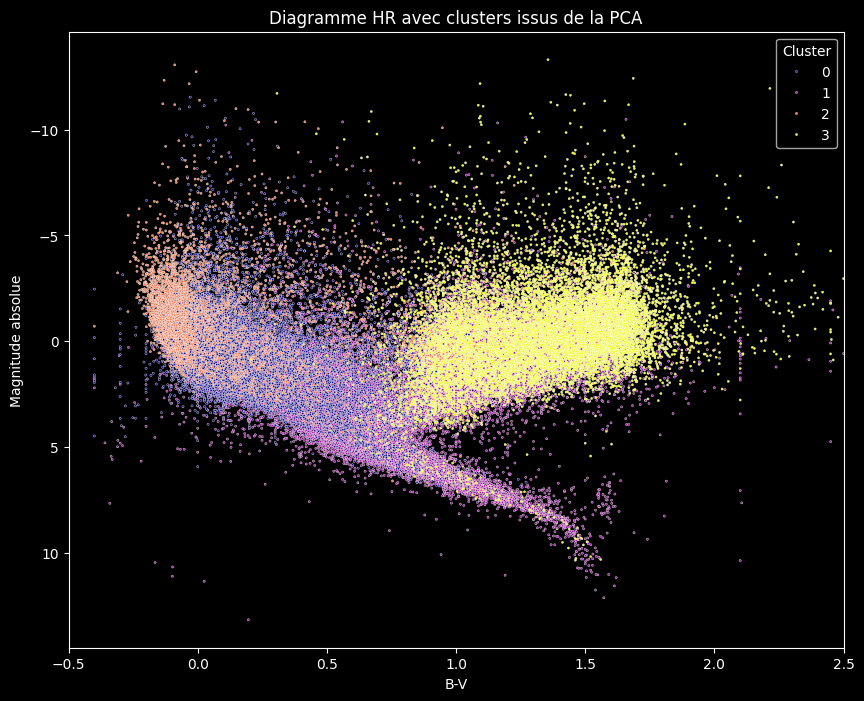

In [259]:
# Faire une copie propre des données utilisées pour la PCA (mêmes dimensions)
data_hr = data_pca_modified_3.copy()
data_hr = data_hr.reset_index(drop=True)

# Ajouter les labels des clusters
data_hr['Cluster'] = kmeans.labels_

# Diagramme HR : B-V vs AbsoluteMag
plt.figure(figsize=(10, 8))
plt.style.use('dark_background')
sns.scatterplot(x=data_hr['B-V'], y=data_hr['AbsoluteMag'], hue=data_hr['Cluster'], palette='plasma', marker='.', s=10)
plt.title("Diagramme HR avec clusters issus de la PCA")
plt.xlim(-0.5, 2.5)
plt.xlabel('B-V')
plt.ylabel('Magnitude absolue')
plt.gca().invert_yaxis() 
plt.show()


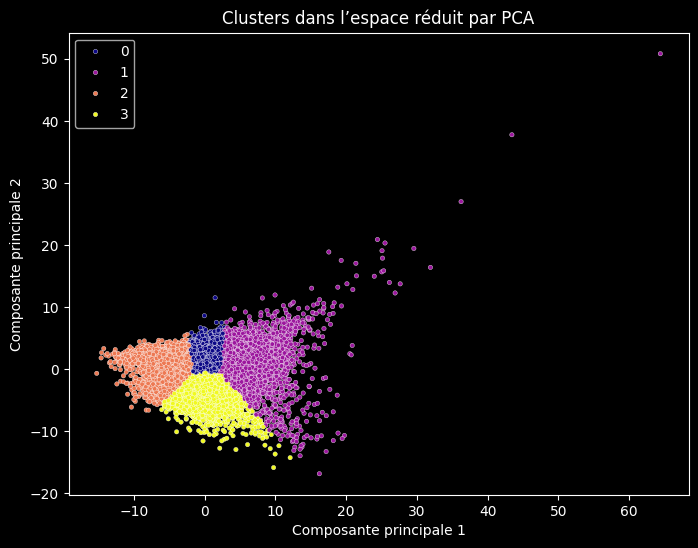

In [260]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=data_t_df['Col1'], y=data_t_df['Col2'], hue=labels, palette='plasma', s=10)
plt.title("Clusters dans l’espace réduit par PCA")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.show()

In [261]:
score = silhouette_score(data_t_df, labels)
print("Score silhouette moyen :", score)

Score silhouette moyen : 0.3504410681049896


In [262]:
def pca_kmeans(nb_comp, nb_cluster) :

    # Appliquer la PCA
    pca = decomposition.PCA(n_components=nb_comp)
    pca.fit(data_scaled_df_pca)  # c'est important d'utiliser les données normalisées 
    data_t = pca.transform(data_scaled_df_pca)
    col_names = [f"PC{i+1}" for i in range(nb_comp)]
    data_t_df = pd.DataFrame(data_t, columns=col_names)
    print("Variance expliquée :", pca.explained_variance_ratio_)

    # Entraînement du modèle
    kmeans = KMeans(n_clusters=nb_cluster, random_state=0, n_init=10)
    kmeans.fit(data_t_df)

    # Faire une copie propre des données utilisées pour la PCA (mêmes dimensions)
    data_hr = data_pca_modified_3.copy()
    data_hr = data_hr.reset_index(drop=True)

    # Ajouter les labels des clusters
    data_hr['Cluster'] = kmeans.labels_

    # Diagramme HR : B-V vs AbsoluteMag
    plt.figure(figsize=(10, 8))
    plt.style.use('dark_background')
    sns.scatterplot(x=data_hr['B-V'], y=data_hr['AbsoluteMag'], hue=data_hr['Cluster'], palette='plasma', marker='.', s=10)
    plt.title(f"Diagramme HR avec PCA ({nb_comp} composantes) et {nb_cluster} clusters")
    plt.xlim(-0.5, 2.5)
    plt.xlabel('B-V')
    plt.ylabel('Magnitude absolue')
    plt.gca().invert_yaxis() 
    plt.show()


Variance expliquée : [0.17741568 0.09668635]


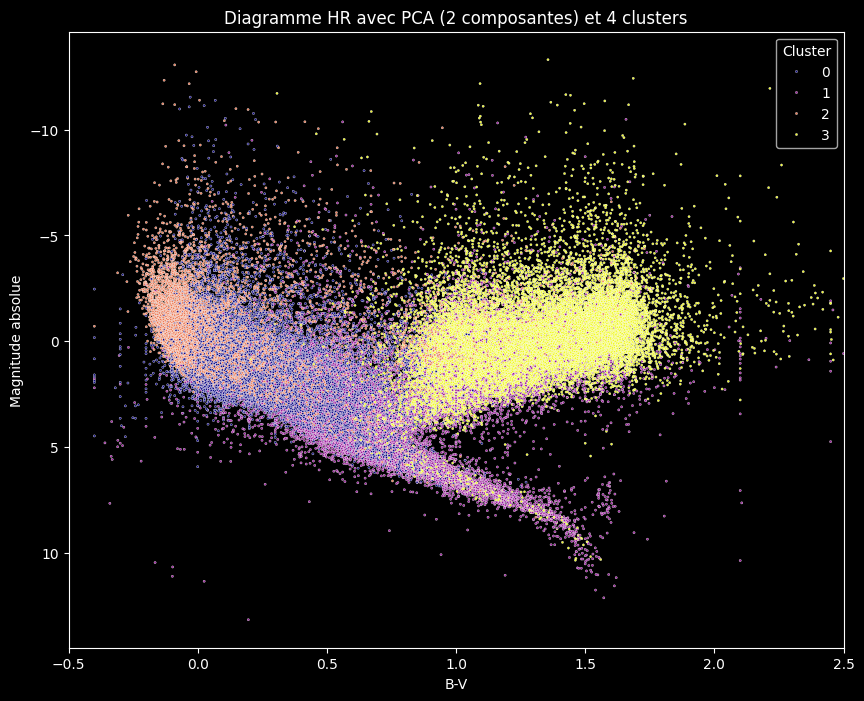

In [263]:
pca_kmeans(2, 4)

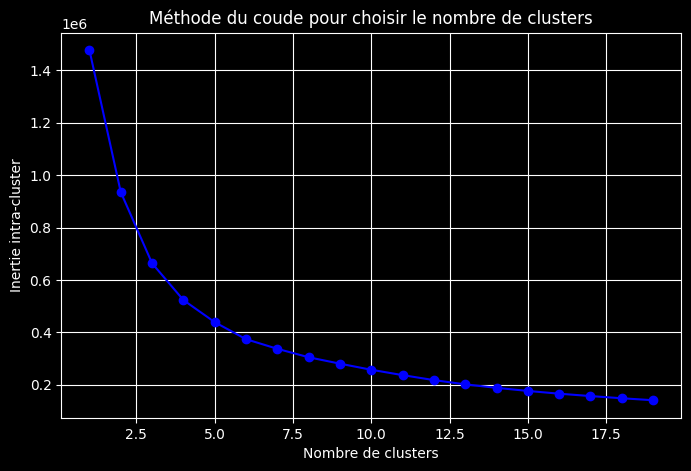

In [264]:
inertias = []
cluster_range = range(1, 20)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)  # n_init : nombre d'initialisations (points de départ différents pour chaque initialisation)
    kmeans.fit(data_t_df)  
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertias, marker='o', color="blue")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie intra-cluster")
plt.title("Méthode du coude pour choisir le nombre de clusters")
plt.grid()
plt.show()


On observe qu’au début, l’inertie diminue fortement lorsque le nombre de clusters augmente (jusqu’à environ 4). Ensuite, la diminution devient plus progressive. Ce changement de rythme correspond au "coude". On peut donc choisir le nombre optimal de clusters au niveau de ce coude, là où l’ajout de nouveaux clusters n’apporte plus d’amélioration significative. 

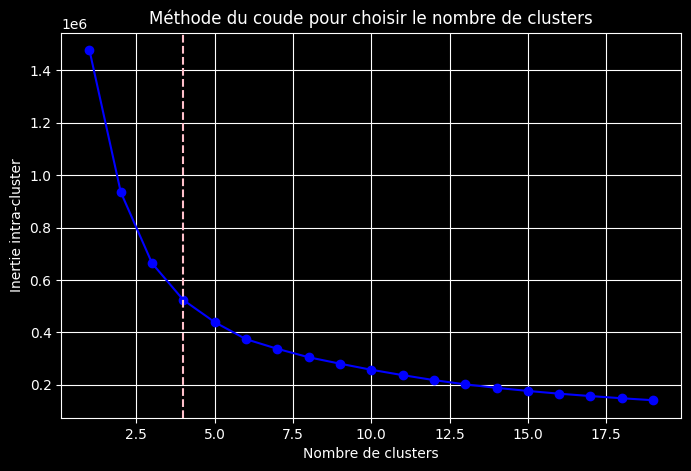

In [265]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertias, marker='o', color="blue")
plt.axvline(x=4, linestyle='--', color='pink')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie intra-cluster")
plt.title("Méthode du coude pour choisir le nombre de clusters")
plt.grid()
plt.show()

On essaye de labelliser les données.

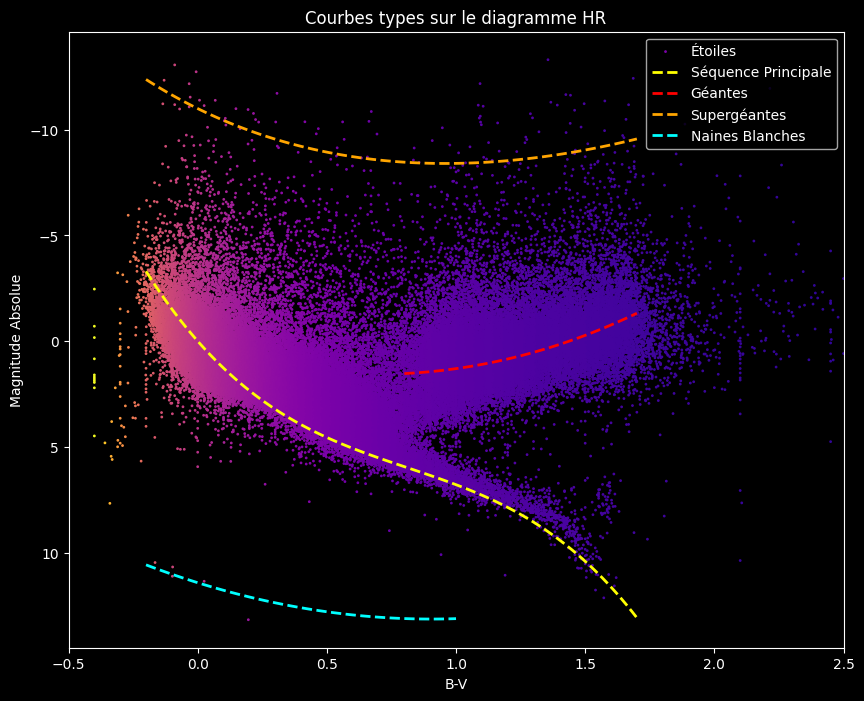

In [329]:

def mag_seq_princ(bv):
    return 4.95 * bv**3 - 12.07 * bv**2 + 13.91 * bv

def mag_geantes(bv):
    return -2.1 * bv**2.2 + 2.9 * bv + 0.5

def mag_supergiantes(bv):
    return -6 * np.exp(-bv) - 1.2 * bv**2 - 5

def mag_naines_blanches(bv):
    return -2.1 * (bv + 0.5)**2 + 5.9 * (bv + 0.5) + 9

bv_seq_princ = np.linspace(-0.2, 1.7, 100)
bv_geantes = np.linspace(0.8, 1.7, 100) 
bv_superg = np.linspace(-0.2, 1.7, 100) 
bv_naine_blanche = np.linspace(-0.2, 1.0, 100)

abs_mag_seq_princ = mag_seq_princ(bv_seq_princ)
abs_mag_geantes = mag_geantes(bv_geantes)
abs_mag_superg = mag_supergiantes(bv_superg)
abs_mag_naine_blanche = mag_naines_blanches(bv_naine_blanche)

# Tracer les courbes
plt.figure(figsize=(10, 8))
plt.scatter(data_hr['B-V'], data_hr['AbsoluteMag'], s=1, c=data_hr['Temperature'], cmap="plasma", label='Étoiles')
plt.plot(bv_seq_princ, abs_mag_seq_princ, color='yellow', linestyle='--', linewidth=2, label='Séquence Principale')
plt.plot(bv_geantes, abs_mag_geantes, color='red', linestyle='--', linewidth=2, label='Géantes')
plt.plot(bv_superg, abs_mag_superg, color='orange', linestyle='--', linewidth=2, label='Supergéantes')
plt.plot(bv_naine_blanche, abs_mag_naine_blanche, color='cyan', linestyle='--', linewidth=2, label='Naines Blanches')
plt.gca().invert_yaxis()
plt.xlim(-0.5, 2.5)
plt.xlabel("B-V")
plt.ylabel("Magnitude Absolue")
plt.title("Courbes types sur le diagramme HR")
plt.legend()
plt.show()


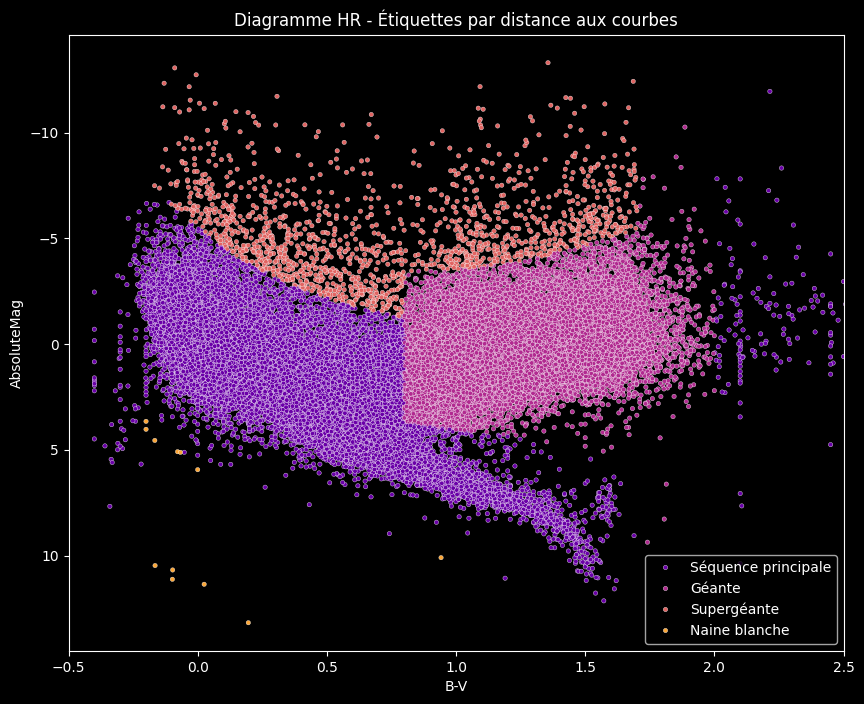

In [334]:
def labelliser_etoile(row):
    bv = row['B-V']
    mag = row['AbsoluteMag']
    
    if np.isnan(bv) or np.isnan(mag):
        return np.nan

    distances = {}

    if -0.2 <= bv <= 1.7:
        distances['Séquence principale'] = abs(mag - mag_seq_princ(bv))
    else:
        distances['Séquence principale'] = np.inf

    if 0.8 <= bv <= 2.0:
        distances['Géante'] = abs(mag - mag_geantes(bv))
    else:
        distances['Géante'] = np.inf

    if -0.2 <= bv <= 1.7:
        distances['Supergéante'] = abs(mag - mag_supergiantes(bv))
    else:
        distances['Supergéante'] = np.inf

    if -0.2 <= bv <= 1.0:
        distances['Naine blanche'] = abs(mag - mag_naines_blanches(bv))
    else:
        distances['Naine blanche'] = np.inf

    return min(distances, key=distances.get)



data_hr['Type_Étoile'] = data_hr.apply(labelliser_etoile, axis=1)



plt.figure(figsize=(10, 8))
sns.scatterplot(data=data_hr, x='B-V', y='AbsoluteMag', hue='Type_Étoile', palette='plasma', s= 10)
plt.gca().invert_yaxis()
plt.xlim(-0.5, 2.5)
plt.title("Diagramme HR - Étiquettes par distance aux courbes")
plt.legend()
plt.show()


Maintenant on peut comparer courbe cluster et courbe "theorique" 

In [270]:
"""
Données réelles --> [normalisation] --> données normalisées --> [PCA] --> données réduites --> [clustering]
        |                                                                                     |
        |                                                                                     V
        ------------------> Récupère les labels de cluster <---------------------- Ajouter dans données réelles
"""



"""trouver meilleure visualisation, faire les autres méthodes et essayer de trouver label pour comparer"""

'trouver meilleure visualisation, faire les autres méthodes et essayer de trouver label pour comparer'

## 5) DBSCAN (sans PCA)

## 6) DBSCAN (avec PCA)

## 7) Bibliographie

https://www.cosmos.esa.int/documents/532822/552851/vol1_all.pdf/99adf6e3-6893-4824-8fc2-8d3c9cbba2b5